# exp07_adveccion — features espaciales (advección)

Sobre 144 nodos (Cd. Victoria). Versiones:
- **v1**: `adveccion` (vecinos r1, gradientes, -(u·gx+v·gy)).
- **v2**: + `nubes` (opacity encoding de cloud_type + fracción nublada).
- **v3**: + `adveccion_upwind` (upwind semi-Lagrangiano, vecindario **r2** 5×5, nube espacial).
- **v4** (por defecto): + vecindario **r3** (7×7, ~26 km) además del r2.

Reproducir: `python -m forecasting.experiments.run exp07_adveccion --version v4`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from forecasting.experiments.reporte import ReporteExperimento
from forecasting.data.loaders import cargar_metadata

r = ReporteExperimento.de('exp07_adveccion', version='v4', ejecutar=False)   # r2 + r3
v3 = ReporteExperimento.de('exp07_adveccion', version='v3', ejecutar=False)  # solo r2
r.resumen()

exp07_adveccion v4 | feature-set base-nocturno-viento-cielo-nubes-adveccion-adveccion_upwind_r23 (64 feats) | best_iter 386
Test global: RMSE 75.42 vs persist 86.41 | skill 0.1272 | R² 0.934


## Progresión de skill entre versiones (test global)

In [2]:
filas = []
for v in ['v1','v2','v3','v4']:
    rr = ReporteExperimento.de('exp07_adveccion', version=v, ejecutar=False)
    g = rr.metrics_global; t = g[(g.split=='test') & (g.segmento=='global')].iloc[0]
    filas.append({'version': v, 'n_features': rr.config['n_features'],
                  'RMSE': round(t.RMSE_modelo,2), 'skill': round(t.skill,4)})
pd.DataFrame(filas)

,version,n_features,RMSE,skill
0,v1,58,76.84,0.1107
1,v2,60,76.76,0.1117
2,v3,63,75.93,0.1213
3,v4,64,75.42,0.1272


## Mapa: los 144 nodos usados (bloque 12×12 alrededor de Cd. Victoria)

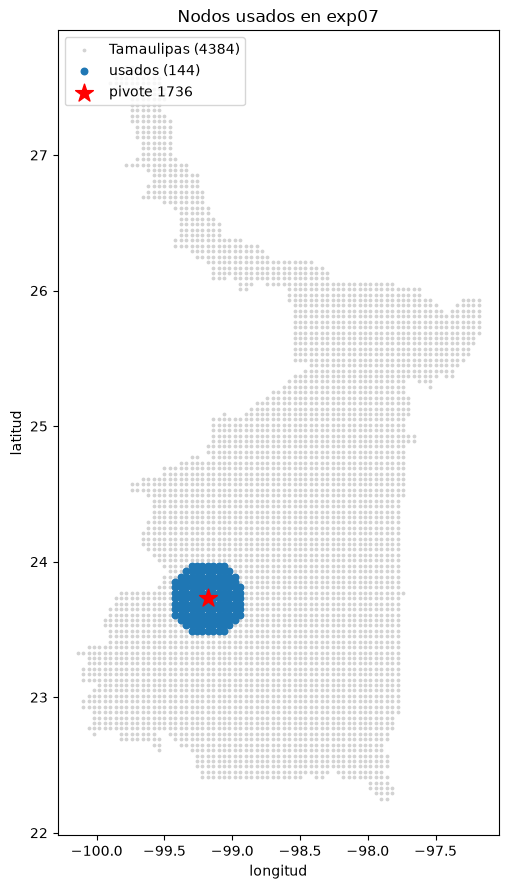

In [3]:
todos = cargar_metadata(); usados = set(r.por_nodo.nodo_id); pivote = 1736
fig, ax = plt.subplots(figsize=(7, 9))
ax.scatter(todos.longitude, todos.latitude, s=3, c='lightgray', label='Tamaulipas (4384)')
u = todos[todos.nodo_id.isin(usados)]
ax.scatter(u.longitude, u.latitude, s=22, c='tab:blue', label='usados (144)')
p = todos[todos.nodo_id == pivote]
ax.scatter(p.longitude, p.latitude, s=180, marker='*', c='red', label='pivote 1736')
ax.set_xlabel('longitud'); ax.set_ylabel('latitud'); ax.legend(loc='upper left')
ax.set_title('Nodos usados en exp07'); ax.set_aspect('equal'); plt.tight_layout(); plt.show()

## Efecto del radio 3 (v3 → v4), por régimen

In [4]:
def comparar(a, b, col):
    m = a[[col,'n','skill']].merge(b[[col,'skill']], on=col, suffixes=('_v3','_v4'))
    m['delta'] = (m['skill_v4'] - m['skill_v3']).round(4); return m.round(3)
display(comparar(v3.regimen_rampa, r.regimen_rampa, 'regimen_rampa'))
display(comparar(v3.regimen_nubosidad, r.regimen_nubosidad, 'regimen_nubosidad'))

,regimen_rampa,n,skill_v3,skill_v4,delta
0,rampa suave (<0.1),408158,-0.708,-0.666,0.042
1,rampa moderada (0.1-0.25),112163,0.124,0.130,0.006
2,rampa fuerte (>0.25),73305,0.218,0.218,0.000


,regimen_nubosidad,n,skill_v3,skill_v4,delta
0,cubierto (kt<0.3),40469,0.017,0.029,0.012
1,parcial (0.3-0.7),104991,0.149,0.153,0.004
2,despejado (kt>=0.7),448310,0.144,0.148,0.004


## Importancias — r2 vs r3

`kt_vecinos_mean_r2` sigue dominando (2ª); `kt_vecinos_mean_r3` aporta pero menos
(rendimientos decrecientes al ampliar el vecindario).

,index,gain,rank
1,kt_vecinos_mean_r2,0.118453,2
2,cloud_op_vecinos_mean,0.068157,3
4,kt_vecinos_mean_r3,0.036871,5
39,kt_upwind,0.002126,40


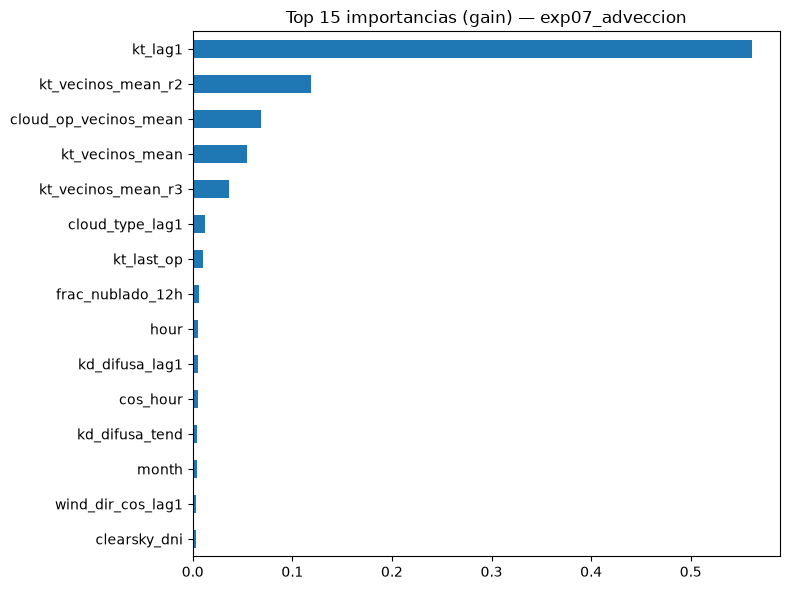

In [5]:
imp = r.importancias.reset_index(); imp['rank'] = range(1, len(imp)+1)
display(imp[imp['index'].str.contains('vecinos_mean_r|cloud_op_vecinos|upwind')][['index','gain','rank']])
r.plot_importancias(15); plt.tight_layout(); plt.show()

## Momentos difíciles (nodo 1736): RMSE diario y series v3 vs v4

In [6]:
def serie_local(rep, nodo=1736, tz=-6):
    p = rep.predicciones; p = p[p.nodo_id == nodo].copy()
    p.index = p.index + pd.Timedelta(hours=tz); return p
p3, p4 = serie_local(v3), serie_local(r)
def rmse_dia(p, col): return ((p[col]-p['ghi_true'])**2).groupby(p.index.date).mean()**0.5
tab = pd.DataFrame({'persistence': rmse_dia(p4,'ghi_persistence'),
                    'exp07_v3': rmse_dia(p3,'ghi_pred'), 'exp07_v4': rmse_dia(p4,'ghi_pred')})
tab['mejora_v4_vs_v3'] = (tab['exp07_v3'] - tab['exp07_v4']).round(1)
dias = tab.sort_values('exp07_v4', ascending=False).head(10)
display(dias.round(1))

,persistence,exp07_v3,exp07_v4,mejora_v4_vs_v3
2024-02-14,274.3,233.6,231.8,1.8
2024-01-04,254.8,217.1,218.6,-1.4
2024-10-07,250.0,204.2,204.2,0.0
2024-05-24,200.8,175.7,182.6,-6.9
2024-05-27,200.1,174.1,176.7,-2.6
2024-05-25,200.3,169.5,174.5,-5.0
2024-12-25,206.8,165.9,168.6,-2.6
2024-06-04,197.9,184.3,162.9,21.4
2024-09-15,180.3,160.7,160.9,-0.2
2024-06-03,161.9,160.2,157.5,2.7


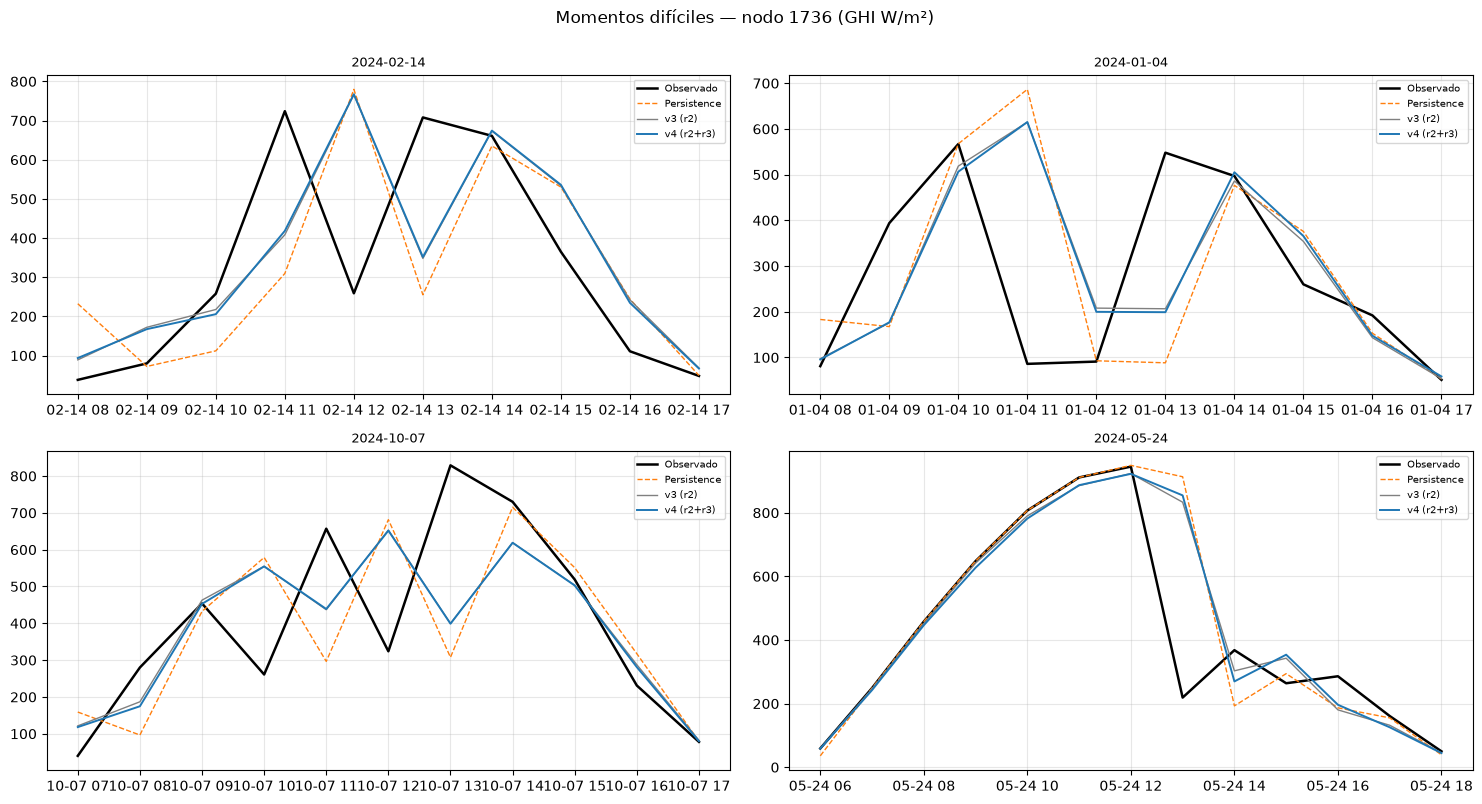

In [7]:
fechas = list(dias.index[:4])
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, f in zip(axes.ravel(), fechas):
    a3 = p3[p3.index.date == f]; a4 = p4[p4.index.date == f]
    ax.plot(a4.index, a4['ghi_true'], 'k', lw=1.8, label='Observado')
    ax.plot(a4.index, a4['ghi_persistence'], '--', color='tab:orange', lw=1, label='Persistence')
    ax.plot(a3.index, a3['ghi_pred'], color='gray', lw=1, label='v3 (r2)')
    ax.plot(a4.index, a4['ghi_pred'], color='tab:blue', lw=1.4, label='v4 (r2+r3)')
    ax.set_title(str(f), fontsize=9); ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.suptitle('Momentos difíciles — nodo 1736 (GHI W/m²)', y=1.0)
plt.tight_layout(); plt.show()

## Métricas globales y por nodo

In [8]:
display(r.metrics_global.round(3))
pn = r.por_nodo
print('skill por nodo: medio %.4f  min %.4f  max %.4f  (%d nodos)' % (
    pn.skill.mean(), pn.skill.min(), pn.skill.max(), len(pn)))

,segmento,n,RMSE_persistence,RMSE_modelo,MAE_modelo,MBE_modelo,R2_persistence,R2_modelo,skill,split
0,global,592312,86.705,75.113,41.008,2.988,0.917,0.938,0.134,val
1,limpio_ff0,539027,88.111,76.296,41.500,2.240,0.909,0.932,0.134,val
2,rellenado_ff_pos,53285,70.935,61.885,36.034,10.552,0.862,0.895,0.128,val
3,global,593770,86.414,75.419,44.017,1.156,0.913,0.934,0.127,test
4,limpio_ff0,538873,87.952,76.814,45.079,1.140,0.903,0.926,0.127,test
5,rellenado_ff_pos,54897,69.529,60.025,33.590,1.322,0.874,0.906,0.137,test


skill por nodo: medio 0.1279  min 0.0700  max 0.1648  (144 nodos)
